In [1]:
##Task:3....Date:13-04-2026
#Linear Regression - House Price Prediction

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Better visualization
sns.set(style="whitegrid")

In [3]:
## Step 1: Load and Explore Dataset

In [4]:
df = pd.read_csv("Housing.csv")

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [6]:
##Step 2: Data Preprocessing

In [7]:
# Check missing values
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [8]:
## Step 3: Train-Test Split

In [10]:
# Features and Target
X = df.drop("price", axis=1)
y = df["price"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (436, 12)
Testing data: (109, 12)


In [11]:
##Step 4: Train Linear Regression Model

In [13]:
# Ensure all data is numeric before training
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Align columns (very important professional step)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")


Model trained successfully!


In [14]:
##Step 5: Predictions

In [15]:
y_pred = model.predict(X_test)

# Compare actual vs predicted
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head()

,Actual,Predicted
0,4060000,5.164654e+06
1,6650000,7.224722e+06
2,3710000,3.109863e+06
3,6440000,4.612075e+06
4,2800000,3.294646e+06


In [16]:
##Step 6: Model Evaluation

In [17]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)

MAE: 970043.4039201637
MSE: 1754318687330.6643
R² Score: 0.6529242642153184


In [18]:
##Step 7: Visualization (Regression Line)

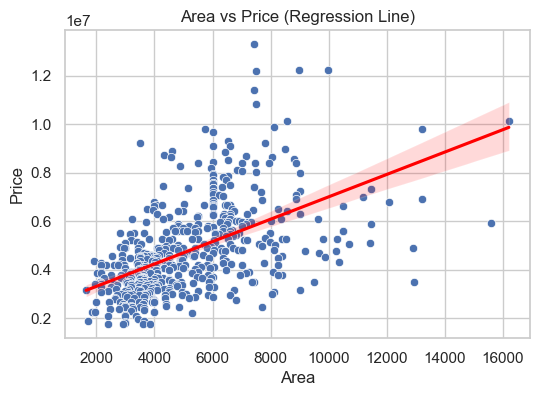

In [20]:
plt.figure(figsize=(6,4))

sns.scatterplot(x=df["area"], y=df["price"])
sns.regplot(x=df["area"], y=df["price"], scatter=False, color='red')

plt.title("Area vs Price (Regression Line)")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

In [21]:
##Step 8: Model Interpretation

##Coefficients represent how much price changes with each feature
##Positive coefficient → Increase in feature increases price
##Negative coefficient → Increase in feature decreases price

In [23]:
coeff_df = pd.DataFrame(model.coef_, X_train.columns, columns=['Coefficient'])
coeff_df

,Coefficient
area,2.359688e+02
bedrooms,7.677870e+04
bathrooms,1.094445e+06
stories,4.074766e+05
parking,2.248419e+05
mainroad_yes,3.679199e+05
guestroom_yes,2.316100e+05
basement_yes,3.902512e+05
hotwaterheating_yes,6.846499e+05
airconditioning_yes,7.914267e+05
